In [1]:
import pandas as pd
import numpy as np

In [2]:
df2=pd.read_csv("Road_Accident_Prevention_Dataset_20000.csv")

In [3]:
df3=df2.copy()

In [4]:
df3.head()

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,Driver_Age,Driver_Gender,Vehicle_Type,Speed_kmph,Alcohol_Involved,Driver_Drowsy,Pothole_Involved,Cause_of_Accident,Severity,Casualties
0,ACC20000,18-01-2023,12:39,Tamil Nadu,Madurai,11.2765,78.0398,Village Road,Rainy,Day,18,Male,Auto,39,No,No,No,Poor Weather Visibility,Low,2.0
1,ACC20001,16-10-2023,18:13,Andhra Pradesh,Guntur,16.2785,79.6676,National Highway,Cloudy,Dusk,34,Male,Bus,83,No,No,No,Over Speeding,Medium,0.0
2,ACC20002,17-05-2024,14:28,Karnataka,Mysuru,14.4623,75.0246,Village Road,Rainy,Day,47,Female,Bike,50,Yes,No,Yes,Poor Weather Visibility,High,7.0
3,ACC20003,15-05-2023,07:54,Andhra Pradesh,Visakhapatnam,15.6972,80.1319,National Highway,Cloudy,Day,53,Male,Bus,65,No,No,No,Poor Weather Visibility,Medium,3.0
4,ACC20004,08-11-2023,09:05,Puducherry,Puducherry,11.7264,80.7346,State Highway,Cloudy,Day,38,Male,Car,80,No,No,No,Over Speeding,Low,1.0


In [5]:
df3.describe()

,Latitude,Longitude,Driver_Age,Speed_kmph,Casualties
count,20000.000000,20000.000000,20000.000000,20000.000000,19207.000000
mean,13.945313,77.886184,36.596600,58.598600,2.486645
std,2.871003,1.621542,12.132243,17.839436,2.385505
min,9.095400,74.320300,18.000000,15.000000,0.000000
25%,11.011575,76.153100,27.000000,45.000000,1.000000
50%,15.066500,78.516000,36.000000,58.000000,2.000000
75%,16.023400,79.193125,45.000000,71.000000,4.000000
max,19.436100,81.380800,75.000000,133.000000,12.000000


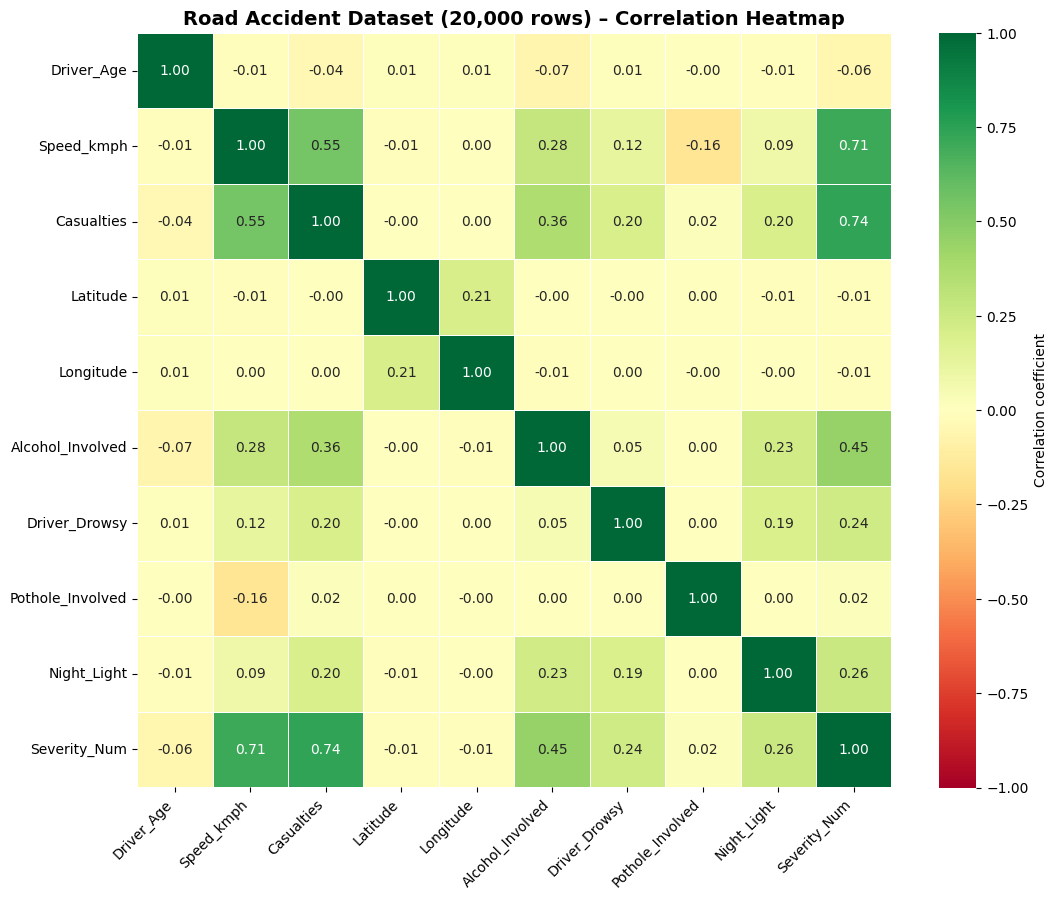

Heatmap saved as accident_correlation_heatmap_20000.png


In [8]:


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. Load data ----
FILE_PATH = "Road_Accident_Prevention_Dataset_20000.csv"   # change path as needed
df3 = pd.read_csv(FILE_PATH)
# ---- 2. Encode categorical columns to numeric ----
enc = pd.DataFrame()
enc["Driver_Age"]       = df3["Driver_Age"]
enc["Speed_kmph"]       = df3["Speed_kmph"]
enc["Casualties"]       = df3["Casualties"]
enc["Latitude"]         = df3["Latitude"]
enc["Longitude"]        = df3["Longitude"]
enc["Alcohol_Involved"] = df3["Alcohol_Involved"].map({"No": 0, "Yes": 1})
enc["Driver_Drowsy"]    = df3["Driver_Drowsy"].map({"No": 0, "Yes": 1})
enc["Pothole_Involved"] = df3["Pothole_Involved"].map({"No": 0, "Yes": 1})
enc["Night_Light"]      = df3["Light_Condition"].map({"Night": 1}).fillna(0)
enc["Severity_Num"]     = df3["Severity"].map({"Low": 1, "Medium": 2, "High": 3})

# ---- 3. Compute correlation matrix ----
corr = enc.corr(method="pearson").round(2)

# ---- 4. Plot heatmap ----
plt.figure(figsize=(11, 9))
sns.heatmap(
    corr,
    annot=True,           # show correlation values
    fmt=".2f",
    cmap="RdYlGn",        # red = negative, green = positive
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Road Accident Dataset (20,000 rows) – Correlation Heatmap", fontsize=14, weight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

# ---- 5. Save output ----
plt.savefig("accident_correlation_heatmap_20000.png", dpi=300)
plt.show()

print("Heatmap saved as accident_correlation_heatmap_20000.png")

In [9]:
# Profile row and column counts per file
df3.shape

(20000, 20)

In [10]:
# Inspect data types for detected columns

df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Accident_ID        20000 non-null  str    
 1   Date               20000 non-null  str    
 2   Time               20000 non-null  str    
 3   State              20000 non-null  str    
 4   District           20000 non-null  str    
 5   Latitude           20000 non-null  float64
 6   Longitude          20000 non-null  float64
 7   Road_Type          20000 non-null  str    
 8   Weather            20000 non-null  str    
 9   Light_Condition    20000 non-null  str    
 10  Driver_Age         20000 non-null  int64  
 11  Driver_Gender      20000 non-null  str    
 12  Vehicle_Type       20000 non-null  str    
 13  Speed_kmph         20000 non-null  int64  
 14  Alcohol_Involved   20000 non-null  str    
 15  Driver_Drowsy      20000 non-null  str    
 16  Pothole_Involved   20000 non-null

In [11]:
# Log missing-value counts per column
df3.isnull().sum()

Accident_ID            0
Date                   0
Time                   0
State                  0
District               0
Latitude               0
Longitude              0
Road_Type              0
Weather                0
Light_Condition        0
Driver_Age             0
Driver_Gender          0
Vehicle_Type           0
Speed_kmph             0
Alcohol_Involved       0
Driver_Drowsy          0
Pothole_Involved       0
Cause_of_Accident      0
Severity               0
Casualties           793
dtype: int64

In [12]:
df3[df3.isnull().any(axis=1)]

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,Driver_Age,Driver_Gender,Vehicle_Type,Speed_kmph,Alcohol_Involved,Driver_Drowsy,Pothole_Involved,Cause_of_Accident,Severity,Casualties
93,ACC20093,29-06-2024,08:57,Telangana,Karimnagar,17.0183,78.8991,Village Road,Foggy,Day,35,Female,Truck,30,No,No,No,Poor Weather Visibility,Low,NaN
143,ACC20143,19-08-2022,07:50,Karnataka,Mysuru,15.4697,75.7651,Expressway,Rainy,Day,40,Male,Bike,73,No,No,No,Poor Weather Visibility,Medium,NaN
167,ACC20167,16-08-2023,06:34,Telangana,Khammam,18.4367,79.3985,State Highway,Clear,Day,43,Female,Car,67,No,No,No,Over Speeding,Low,NaN
179,ACC20179,13-08-2024,14:50,Kerala,Thiruvananthapuram,10.2004,76.1566,National Highway,Rainy,Day,32,Female,Car,64,No,Yes,No,Poor Weather Visibility,Medium,NaN
206,ACC20206,30-11-2023,16:59,Andhra Pradesh,Visakhapatnam,16.1372,79.7560,City Road,Cloudy,Day,54,Male,Bike,42,No,No,Yes,Pothole/Bad Road,Low,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19907,ACC39907,11-03-2023,16:01,Puducherry,Puducherry,11.2342,79.3897,City Road,Foggy,Day,39,Female,Bike,42,No,No,No,Poor Weather Visibility,Low,NaN
19912,ACC39912,20-09-2023,14:30,Tamil Nadu,Salem,11.3310,78.9212,Village Road,Clear,Day,18,Male,Auto,50,No,No,No,Poor Weather Visibility,Low,NaN
19916,ACC39916,16-11-2022,21:38,Andhra Pradesh,Vijayawada,15.9335,79.3977,State Highway,Cloudy,Night,50,Female,Truck,67,No,No,No,Poor Weather Visibility,Medium,NaN
19946,ACC39946,19-04-2024,21:42,Telangana,Hyderabad,17.9724,78.9573,City Road,Clear,Night,39,Female,Bike,53,No,Yes,No,Drowsy Driving,Low,NaN


In [ ]:
df3['Casualties'].mean()

In [13]:
median=df3['Casualties'].median()

In [14]:
df3['Casualties'].mode()

0    1.0
Name: Casualties, dtype: float64

In [16]:
df3['Casualties']=df3['Casualties'].fillna(median)

In [ ]:
# df1['Casualties'].anytype(int)

In [17]:
df3.isnull().sum()

Accident_ID          0
Date                 0
Time                 0
State                0
District             0
Latitude             0
Longitude            0
Road_Type            0
Weather              0
Light_Condition      0
Driver_Age           0
Driver_Gender        0
Vehicle_Type         0
Speed_kmph           0
Alcohol_Involved     0
Driver_Drowsy        0
Pothole_Involved     0
Cause_of_Accident    0
Severity             0
Casualties           0
dtype: int64

In [18]:
# Identify duplicates using Accident_ID
df3['Accident_ID'].duplicated().sum()

np.int64(0)

In [19]:
df3[df3['Accident_ID'].duplicated()]

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,Driver_Age,Driver_Gender,Vehicle_Type,Speed_kmph,Alcohol_Involved,Driver_Drowsy,Pothole_Involved,Cause_of_Accident,Severity,Casualties


In [20]:
df3['Light_Condition'].unique()

<StringArray>
['Day', 'Dusk', 'Dawn', 'Night']
Length: 4, dtype: str

## DAY - 4

In [22]:
## Detect data-type issues (numeric-as-text, malformed dates in Date, Time)
df3['Date']=pd.to_datetime(df3['Date'])

In [23]:
df3['Date'].head()

0   2023-01-18
1   2023-10-16
2   2024-05-17
3   2023-05-15
4   2023-11-08
Name: Date, dtype: datetime64[us]

In [24]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Accident_ID        20000 non-null  str           
 1   Date               20000 non-null  datetime64[us]
 2   Time               20000 non-null  str           
 3   State              20000 non-null  str           
 4   District           20000 non-null  str           
 5   Latitude           20000 non-null  float64       
 6   Longitude          20000 non-null  float64       
 7   Road_Type          20000 non-null  str           
 8   Weather            20000 non-null  str           
 9   Light_Condition    20000 non-null  str           
 10  Driver_Age         20000 non-null  int64         
 11  Driver_Gender      20000 non-null  str           
 12  Vehicle_Type       20000 non-null  str           
 13  Speed_kmph         20000 non-null  int64         
 14  Alcohol_Involved 

In [25]:
## Detect invalid values / out-of-range in Driver_Age
df3['Driver_Age'].unique()

array([18, 34, 47, 53, 38, 45, 51, 35, 44, 25, 21, 24, 23, 26, 30, 54, 48,
       29, 49, 31, 27, 20, 58, 32, 19, 22, 39, 46, 56, 40, 37, 41, 57, 28,
       33, 59, 36, 43, 50, 61, 63, 52, 42, 55, 73, 75, 67, 70, 66, 64, 60,
       71, 69, 62, 68, 72, 65, 74])

In [26]:
## Detect inconsistent categories in State, Road_Type, Driver_Gender 
df3['State'].unique()

<StringArray>
[    'Tamil Nadu', 'Andhra Pradesh',      'Karnataka',     'Puducherry',
         'Kerala',      'Telangana']
Length: 6, dtype: str

In [27]:
df3['Road_Type'].unique()

<StringArray>
['Village Road', 'National Highway', 'State Highway', 'City Road',
 'Expressway']
Length: 5, dtype: str

In [28]:
df3['Driver_Gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [29]:
df3['State'].value_counts()

State
Tamil Nadu        4851
Karnataka         4440
Telangana         3661
Andhra Pradesh    3172
Kerala            3120
Puducherry         756
Name: count, dtype: int64

In [30]:
df3['Casualties']=df3['Casualties'].astype(int)

In [31]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Accident_ID        20000 non-null  str           
 1   Date               20000 non-null  datetime64[us]
 2   Time               20000 non-null  str           
 3   State              20000 non-null  str           
 4   District           20000 non-null  str           
 5   Latitude           20000 non-null  float64       
 6   Longitude          20000 non-null  float64       
 7   Road_Type          20000 non-null  str           
 8   Weather            20000 non-null  str           
 9   Light_Condition    20000 non-null  str           
 10  Driver_Age         20000 non-null  int64         
 11  Driver_Gender      20000 non-null  str           
 12  Vehicle_Type       20000 non-null  str           
 13  Speed_kmph         20000 non-null  int64         
 14  Alcohol_Involved 

In [32]:
df3.head()

,Accident_ID,Date,Time,State,District,Latitude,Longitude,Road_Type,Weather,Light_Condition,Driver_Age,Driver_Gender,Vehicle_Type,Speed_kmph,Alcohol_Involved,Driver_Drowsy,Pothole_Involved,Cause_of_Accident,Severity,Casualties
0,ACC20000,2023-01-18,12:39,Tamil Nadu,Madurai,11.2765,78.0398,Village Road,Rainy,Day,18,Male,Auto,39,No,No,No,Poor Weather Visibility,Low,2
1,ACC20001,2023-10-16,18:13,Andhra Pradesh,Guntur,16.2785,79.6676,National Highway,Cloudy,Dusk,34,Male,Bus,83,No,No,No,Over Speeding,Medium,0
2,ACC20002,2024-05-17,14:28,Karnataka,Mysuru,14.4623,75.0246,Village Road,Rainy,Day,47,Female,Bike,50,Yes,No,Yes,Poor Weather Visibility,High,7
3,ACC20003,2023-05-15,07:54,Andhra Pradesh,Visakhapatnam,15.6972,80.1319,National Highway,Cloudy,Day,53,Male,Bus,65,No,No,No,Poor Weather Visibility,Medium,3
4,ACC20004,2023-11-08,09:05,Puducherry,Puducherry,11.7264,80.7346,State Highway,Cloudy,Day,38,Male,Car,80,No,No,No,Over Speeding,Low,1



## Summary of Findings

* Converted the **Date** column to the correct `datetime` data type.
* Verified that the **Time** column follows the `HH:MM` format and contains no malformed values.
* Validated the **Driver_Age** column for out-of-range or invalid values.
* Standardized categorical values in **State**, **Road_Type**, and **Driver_Gender** by removing unnecessary spaces and checking for inconsistencies.
* Confirmed that the cleaned dataset is consistent and ready for further analysis and visualization.


In [35]:
df3.to_csv("Road_Accident_Prevention_Clean.csv",index=False)

In [34]:
df3.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Accident_ID        20000 non-null  str           
 1   Date               20000 non-null  datetime64[us]
 2   Time               20000 non-null  str           
 3   State              20000 non-null  str           
 4   District           20000 non-null  str           
 5   Latitude           20000 non-null  float64       
 6   Longitude          20000 non-null  float64       
 7   Road_Type          20000 non-null  str           
 8   Weather            20000 non-null  str           
 9   Light_Condition    20000 non-null  str           
 10  Driver_Age         20000 non-null  int64         
 11  Driver_Gender      20000 non-null  str           
 12  Vehicle_Type       20000 non-null  str           
 13  Speed_kmph         20000 non-null  int64         
 14  Alcohol_Involved 

In [36]:
df3.isnull().sum()

Accident_ID          0
Date                 0
Time                 0
State                0
District             0
Latitude             0
Longitude            0
Road_Type            0
Weather              0
Light_Condition      0
Driver_Age           0
Driver_Gender        0
Vehicle_Type         0
Speed_kmph           0
Alcohol_Involved     0
Driver_Drowsy        0
Pothole_Involved     0
Cause_of_Accident    0
Severity             0
Casualties           0
dtype: int64